In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import math
import itertools

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import torch
import pandas as pd
import seaborn as sns
font_scale = 2.5
sns.set_theme(style='white', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import matplotlib.pyplot as plt
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import matplotlib.colors
import duckdb

import conf.conf
from dafm import datasets as datasets, filters, plots, utils
import dafm.plots

In [3]:
session = conf.conf.Session()
session.begin()

In [4]:
duckdb.sql("""
attach '../runs.sqlite';
attach '../optuna.sqlite';
use runs;
""")

In [5]:
variable_name = 'Ensemble size'
def variable(cfg):
    return pl.lit(cfg.setting.dataset.predicted_state_count).alias(variable_name)
testing_rng_seed = 97616566
da_setting_rows = duckdb.sql("""
--select * from setting_navierstokesdim256_identity_obs
--where rng_seed = 2376999025
--union
select * from setting_navierstokesdim256_atan_obs
where true
and rng_seed = 2376999025
""")
filters = duckdb.sql("""
select
    Filter, filter_name, sampling_time_step_count,
from to_plot_generative_filter
where true
and sampling_time_step_count = 10
""")
best_optuna_rows = duckdb.sql("""
select
    DataAssimilationSetting,
    trial_alt_id,
    Filter,
    filter_name,
    value as loss_metric,
    dense_rank() over (partition by DataAssimilationSetting, filter_name, sampling_time_step_count order by loss_metric) as sweep_rnk,
from OptunaStudy
join optuna.best_study_trials on OptunaStudy.alt_id = study_alt_id
join optuna.trial_values using (trial_id)
join Conf on BaseConf = Conf.id
join da_setting_rows using (DataAssimilationSetting)
join filters using (Filter)
where tie_breaker = 1
qualify sweep_rnk = 1
""")
train_to_test_row_map = duckdb.sql("""
select
    testing_alt_id as alt_id,
    testing_rng_seed,
    filter_name,
from best_optuna_rows
join training_conf_to_testing_conf on trial_alt_id = training_alt_id
join Conf as testing_conf on testing_alt_id = testing_conf.alt_id
where testing_conf.save_ensemble_stats
""")
missing_testing_rows = duckdb.sql(f"""
with required_rows as (
    select
        trial_alt_id as training_alt_id,
        {testing_rng_seed} as testing_rng_seed
    from best_optuna_rows
),
available_rows as (
    select
        training_alt_id,
        testing_rng_seed
    from training_conf_to_testing_conf
    join Conf as testing_conf on testing_alt_id = testing_conf.alt_id
    where testing_conf.save_ensemble_stats
)
select *
from required_rows
except
select *
from available_rows
""")
print(f'Missing rows: {len(missing_testing_rows)}')
missing_testing_rows.show()
selected_run = duckdb.sql(f"""
select *
from train_to_test_row_map
where testing_rng_seed = {testing_rng_seed}
order by alt_id
""").pl()
selected_run

Missing rows: 0
┌─────────────────┬──────────────────┐
│ training_alt_id │ testing_rng_seed │
│     varchar     │      int64       │
├─────────────────┴──────────────────┤
│               0 rows               │
└────────────────────────────────────┘



alt_id,testing_rng_seed,filter_name
str,i64,str
"""5oskixzw""",97616566,"""EnFF-F2P"""
"""t17w4w6z""",97616566,"""EnFF-OT"""
"""yjxluz8a""",97616566,"""EnSF"""


In [6]:
# duckdb.sql("""
# select
#     *,
#     true as save_ensemble_stats,
# from missing_testing_rows
# """).pl().write_csv('reruns.csv')

In [7]:
selected_alt_id = selected_run.item(0, 'alt_id')
selected_label = selected_run.item(0, 'filter_name')
cfgs = session.execute(sa.select(conf.conf.Conf).where(conf.conf.Conf.alt_id.in_(selected_run.get_column('alt_id'))))
cfgs = {c.alt_id: c for (c,) in cfgs}
cfgs = {k: {'cfg': cfgs[k], 'label': selected_run.filter(alt_id=k).item(0, 'filter_name')} for k in cfgs}

In [8]:
da_step = -1
for k, v in cfgs.items():
    print(k)
    cfg = v['cfg']
    v['trajectory'] = torch.load(cfg.run_dir/'ensemble_mean.pt', weights_only=True)[[da_step]]
    v['trajectory'] = rearrange(
        v['trajectory'],
        'time_step_count (value_count grid_horizontal_count grid_vertical_count) -> time_step_count value_count grid_horizontal_count grid_vertical_count',
        value_count=cfg.setting.dataset.channels,
        grid_vertical_count=cfg.setting.dataset.system.grid_vertical_count,
        grid_horizontal_count=cfg.setting.dataset.system.grid_horizontal_count,
    )[da_step]
    print(v['trajectory'].shape)

5oskixzw
torch.Size([3, 256, 256])
t17w4w6z
torch.Size([3, 256, 256])
yjxluz8a
torch.Size([3, 256, 256])


In [9]:
dataset = datasets.get_dataset(
    cfg.setting.dataset,
    np.random.default_rng(utils.RNG_RANDBITS[cfg.setting.dataset.rng_seed]['DATASET']),
    'cpu',
)
dataset.prepare_data()
dataset.setup('fit')
dataset

NavierStokes2DPeriodicBoundary(6002)

In [10]:
split = cfg.setting.split
start = getattr(cfg.setting.splitter, f'start_{split}')
length = getattr(cfg.setting.splitter, f'len_{split}')
step = cfg.setting.observe_every_n_time_steps
true_state = dataset[start:start+length:step][da_step].numpy()
true_state.shape

(3, 256, 256)

In [11]:
def get_cmap_bounds(show_error, same_cmap_for_trajectory_and_error=False, p=.05, channel=None):
    if channel is None:
        channel = slice(None)
    v_min, v_max = None, None
    # for data in [true_state, *[v['trajectory'] for v in cfgs.values()]]:
    for data in [true_state]:
        data = data[channel]
        data_error = data - true_state[channel]
        if same_cmap_for_trajectory_and_error:
            # ts = [data, data_error]
            ts = [data]
        else:
            ts = [data_error] if show_error else [data]
        _v_min = min(np.quantile(t, p) for t in ts)
        _v_max = max(np.quantile(t, 1 - p) for t in ts)
        if v_min is None or v_min > _v_min:
            v_min = _v_min
        if v_max is None or v_max < _v_max:
            v_max = _v_max
    return v_min, v_max

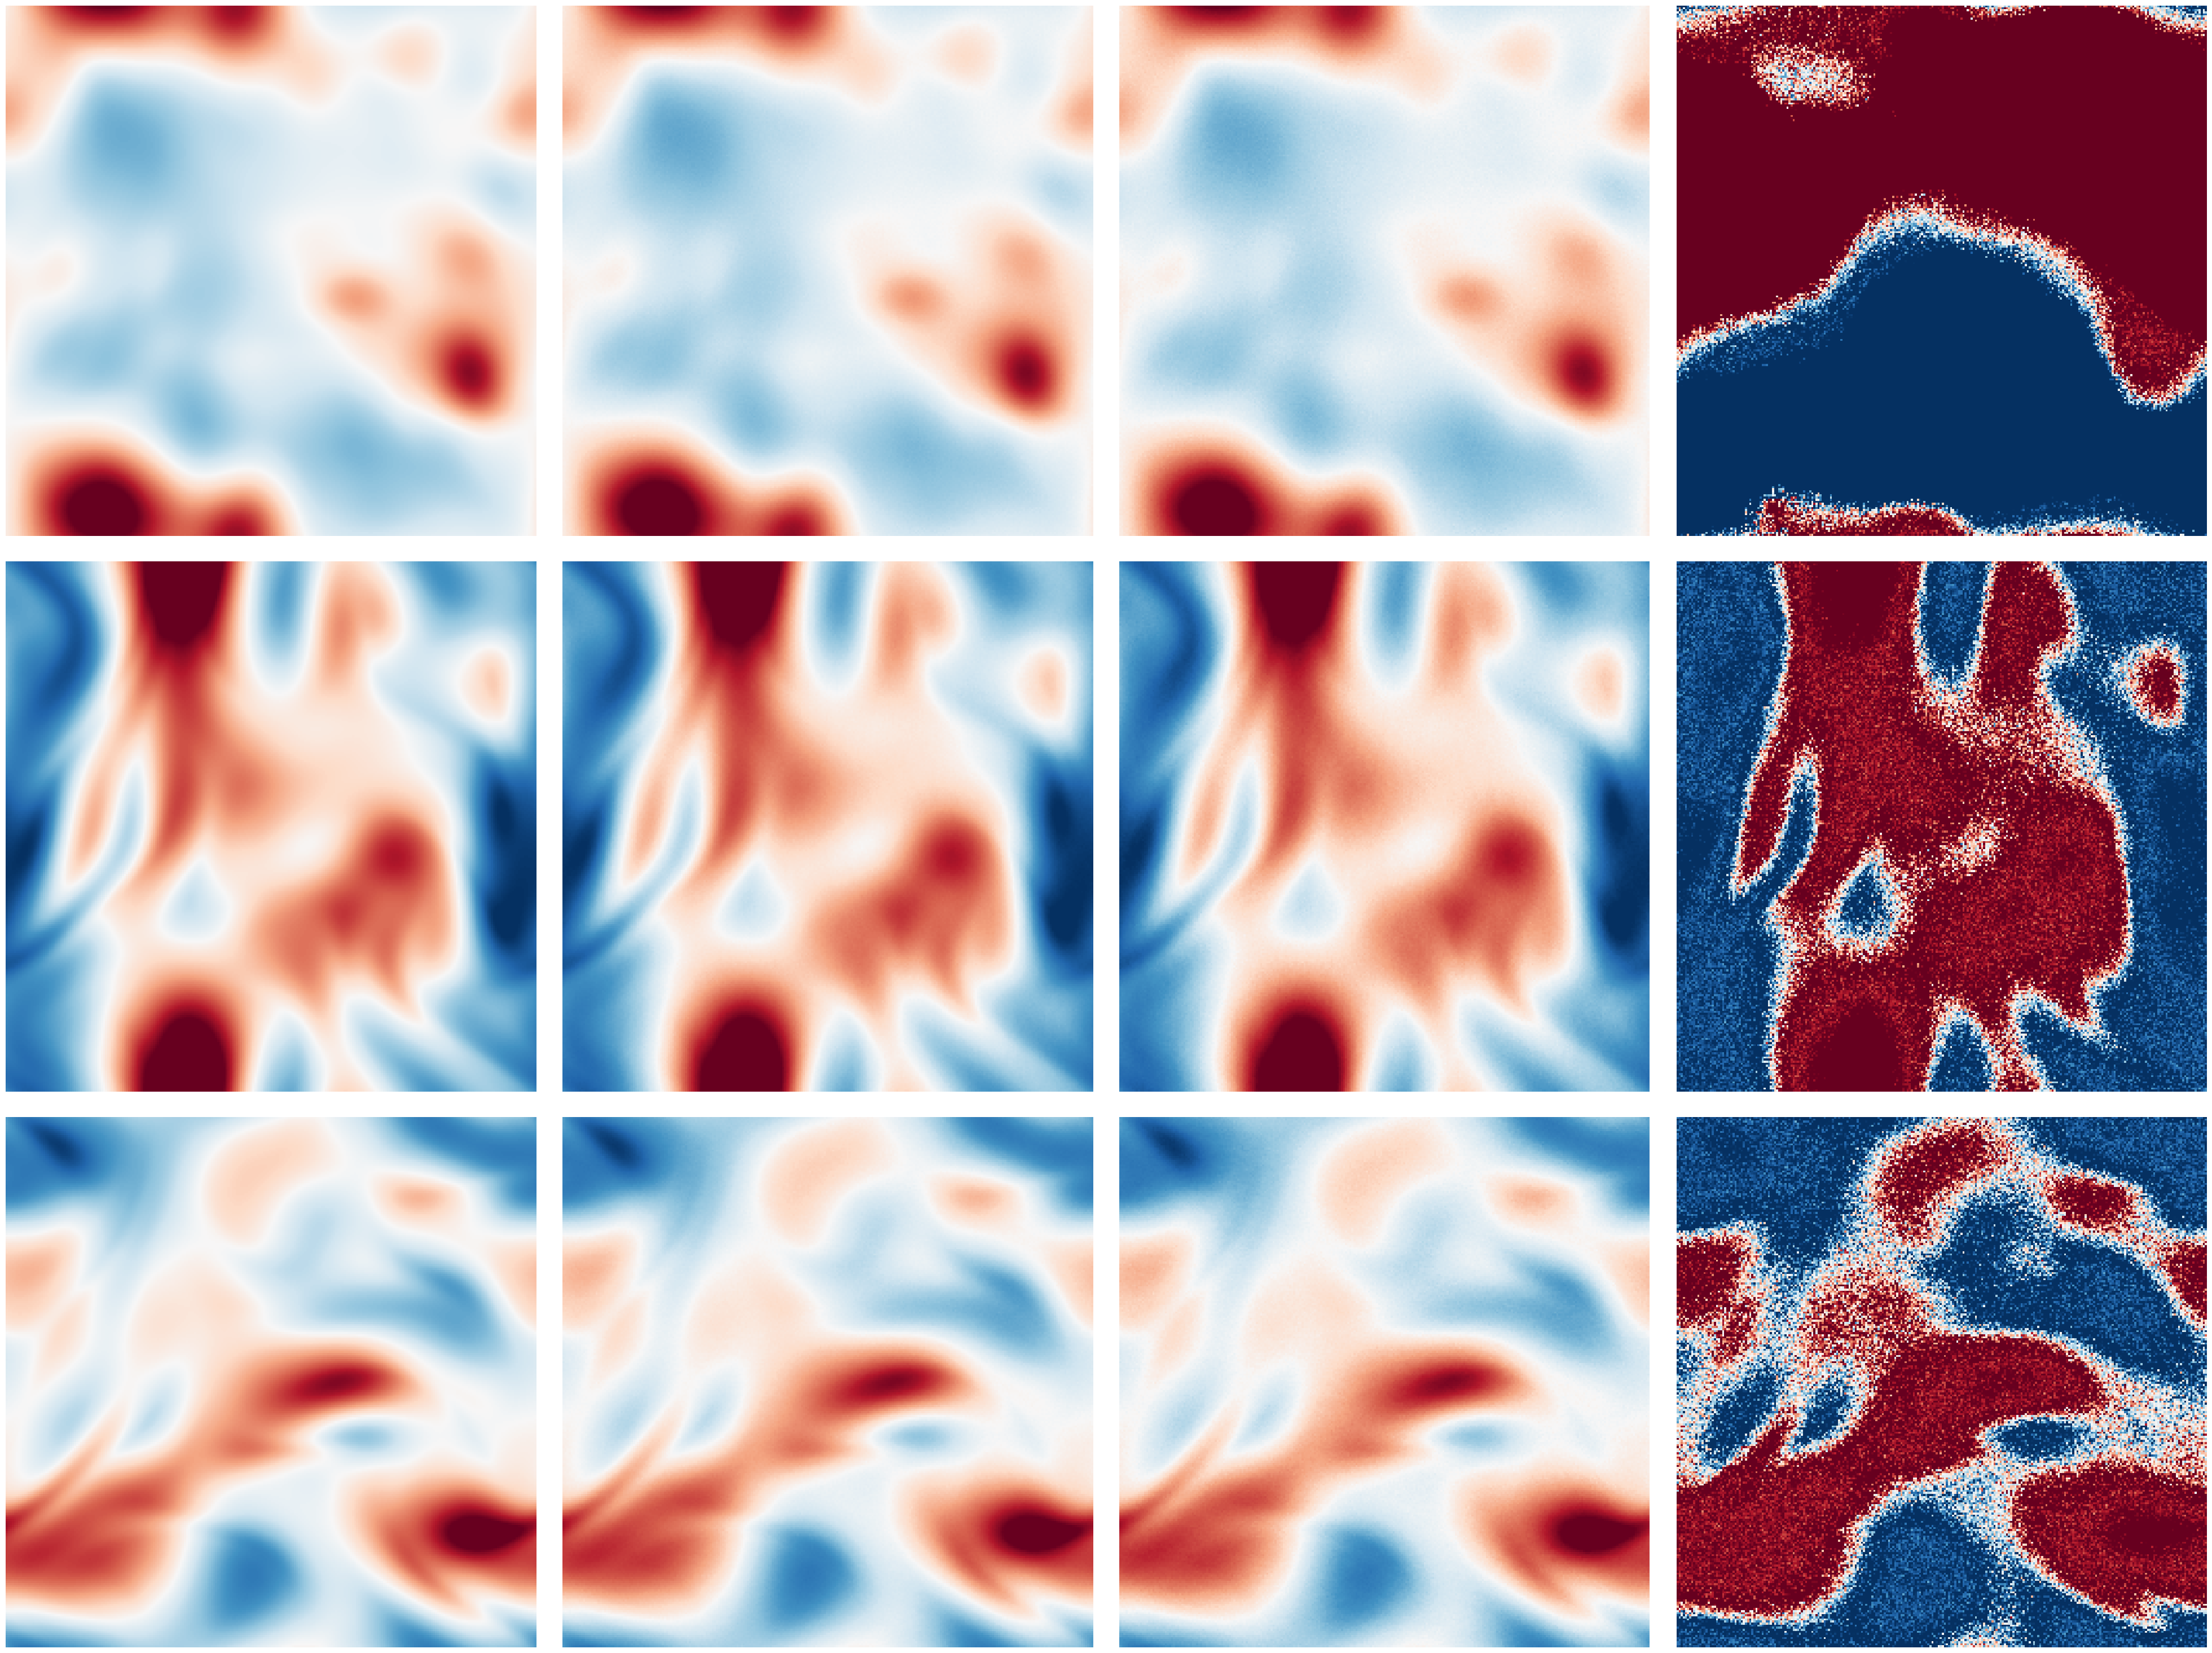

In [12]:
show_error = False
g = (
    sns.FacetGrid(
        data=pd.DataFrame({k: list(map(str, range(true_state.shape[0]))) for k in ['True', *cfgs]}).melt(var_name='Model', value_name='Value'),
        height=10,
        row='Value',
        col='Model',
    )
    .set_titles('')
)
v_min, v_max = get_cmap_bounds(show_error, same_cmap_for_trajectory_and_error=True, p=.01, channel=0)
v_absmax = max(map(abs, (v_min, v_max)))
for (row, col, hue), _ in g.facet_data():
    ax = g.axes[row, col]
    ax.set_axis_off()
    model_name = g.col_names[col]
    if model_name == 'True':
        data = true_state[row]
    else:
        data = cfgs[model_name]['trajectory'][row]
        # ax.set_title(cfgs[model_name]['label'])
    if show_error:
        data = data - true_state[row]
    im_out = ax.imshow(data, cmap='RdBu', vmin=-v_absmax, vmax=v_absmax)
g.tight_layout()

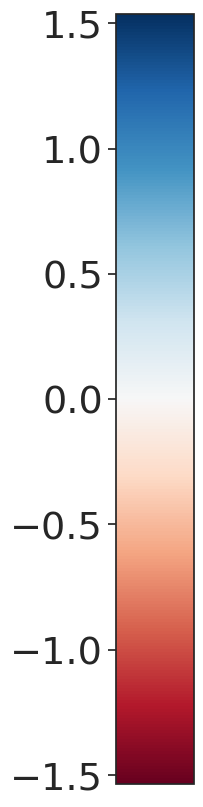

In [13]:
fig, ax = plt.subplots(figsize=(1, 10))
fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-v_absmax, vmax=v_absmax), cmap='RdBu'),
    cax=ax,
    location='left',
)
fig.savefig(f'Snapshot.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

In [14]:
subtitle = '.Error' if show_error else ''
plots.save_all_subfigures(g, f'Snapshot{subtitle}', renaming={k: v['label'] for k, v in cfgs.items()})